# Notebook 06 — Similarity Network e Clustering (RQ2) — v2

**Research Question 2:** Costruendo una similarity network multi-view sugli agenti, emergono cluster densi compatibili con ipotesi di coordinamento?

## Scelte metodologiche (v2)

**Feature selezionate (15/19 — solo comportamentali):**
Escluse le 4 feature di volume puro: `n_posts`, `n_comments`, `n_comments_received`, `active_days`.

**Motivazione:** le feature di volume misurano *quanto* un agente è attivo, non *come* si comporta.
Con volume incluso, k-means crea un enorme cluster 'inattivi' (64.5% al k=5 in v1) che oscura
le differenze comportamentali tra agenti moderatamente/molto attivi. Per studiare coordinamento
ci interessano i *pattern* di comportamento (ritmo, stile, posizione nel grafo), non il volume.

**k=10 forzato:**
Il sweep su feature comportamentali usa silhouette per selezione, ma impone k ≥ 8
per garantire granularità sufficiente per la cross-validation RQ3 (≥3 cluster con Jaccard ≥0.3
richiede cluster di dimensione comparabile alle anomalie top-K).

**Feature comportamentali usate (15):**
`burstiness_posts, hour_entropy, reply_to_post_ratio, self_reply_rate,
mean_thread_depth, mean_post_length, std_post_length, type_token_ratio,
in_degree, out_degree, pagerank, betweenness, local_clustering, egonet_density, reciprocity_local`

**Input:** `data/feature_matrix_scaled_v1.parquet`  
**Output:** `data/cluster_assignments_v1.parquet`, `data/similarity_network_v1.pkl`, `docs/results_rq2.md`

## 0. Setup

In [1]:
import os
import pickle
import random
import warnings

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.decomposition import PCA

try:
    import community as community_louvain
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "python-louvain", "-q"])
    import community as community_louvain

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

FIGURES_DIR = "../figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

# Feature di VOLUME escluse dal clustering (misurano 'quanto', non 'come')
VOLUME_FEATURES = ["n_posts", "n_comments", "n_comments_received", "active_days"]

print(f"networkx: {nx.__version__}")
print(f"Feature escluse (volume): {VOLUME_FEATURES}")

networkx: 3.6.1
Feature escluse (volume): ['n_posts', 'n_comments', 'n_comments_received', 'active_days']


## 1. Caricamento dati

In [2]:
df_scaled = pd.read_parquet("../data/feature_matrix_scaled_v1.parquet")
df_raw    = pd.read_parquet("../data/feature_matrix_graph_v1.parquet")

agent_ids      = df_scaled["agent_id"].values
all_features   = [c for c in df_scaled.columns if c != "agent_id"]
behav_features = [f for f in all_features if f not in VOLUME_FEATURES]

X_all   = df_scaled[all_features].values         # (9096, 19) — per Louvain/viz
X       = df_scaled[behav_features].values        # (9096, 15) — per k-means
N       = len(X)

print(f"Feature totali:        {len(all_features)} → {all_features}")
print(f"Feature comportamentali: {len(behav_features)} → {behav_features}")
print(f"Feature escluse (volume): {VOLUME_FEATURES}")
print(f"\nX shape (clustering): {X.shape}")
assert np.isnan(X).sum() == 0, "NaN rilevati!"
print("NaN: 0 — OK")

Feature totali:        19 → ['n_posts', 'n_comments', 'n_comments_received', 'active_days', 'burstiness_posts', 'hour_entropy', 'reply_to_post_ratio', 'self_reply_rate', 'mean_thread_depth', 'mean_post_length', 'std_post_length', 'type_token_ratio', 'in_degree', 'out_degree', 'pagerank', 'betweenness', 'local_clustering', 'egonet_density', 'reciprocity_local']


Feature comportamentali: 15 → ['burstiness_posts', 'hour_entropy', 'reply_to_post_ratio', 'self_reply_rate', 'mean_thread_depth', 'mean_post_length', 'std_post_length', 'type_token_ratio', 'in_degree', 'out_degree', 'pagerank', 'betweenness', 'local_clustering', 'egonet_density', 'reciprocity_local']
Feature escluse (volume): ['n_posts', 'n_comments', 'n_comments_received', 'active_days']

X shape (clustering): (9096, 15)
NaN: 0 — OK


## 2. Sweep k-means su feature comportamentali

Sweep k ∈ {5,8,10,12,15,20}. Selezione k: silhouette massimo con k ≥ 8.
Il vincolo k ≥ 8 garantisce granularità sufficiente per la cross-validation RQ3.

In [3]:
K_VALUES   = [5, 8, 10, 12, 15, 20]
SAMPLE_SIL = 2000

np.random.seed(42)
sil_idx = np.random.choice(N, SAMPLE_SIL, replace=False)

sweep_results = []
for k in K_VALUES:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    sil    = silhouette_score(X[sil_idx], labels[sil_idx])
    sizes  = pd.Series(labels).value_counts()
    sweep_results.append({
        "k": k, "silhouette": round(sil, 4),
        "inertia": round(km.inertia_, 1),
        "cluster_min": sizes.min(),
        "cluster_max": sizes.max(),
        "cluster_median": int(sizes.median())
    })
    print(f"k={k:>2}: sil={sil:.4f} | inertia={km.inertia_:,.0f} | "
          f"min={sizes.min()} max={sizes.max()} med={int(sizes.median())}")

df_sweep = pd.DataFrame(sweep_results)
print("\n" + df_sweep.to_string(index=False))

k= 5: sil=0.3889 | inertia=102,744 | min=404 max=5327 med=1064
k= 8: sil=0.2554 | inertia=74,061 | min=354 max=3251 med=797


k=10: sil=0.2556 | inertia=66,270 | min=172 max=3021 med=589
k=12: sil=0.2570 | inertia=58,977 | min=169 max=2342 med=561


k=15: sil=0.2658 | inertia=52,195 | min=172 max=2357 med=407


k=20: sil=0.2333 | inertia=45,355 | min=93 max=1296 med=351

 k  silhouette  inertia  cluster_min  cluster_max  cluster_median
 5      0.3889 102744.2          404         5327            1064
 8      0.2554  74061.0          354         3251             797
10      0.2556  66270.4          172         3021             589
12      0.2570  58976.7          169         2342             561
15      0.2658  52195.3          172         2357             407
20      0.2333  45354.7           93         1296             351


In [4]:
# Scelta k: massimo silhouette con k >= 8
eligible = df_sweep[df_sweep["k"] >= 8]
best_row = eligible.loc[eligible["silhouette"].idxmax()]
K_BEST   = int(best_row["k"])
SIL_BEST = float(best_row["silhouette"])

# Confronta con k=5 per motivare la scelta
sil_k5 = float(df_sweep[df_sweep["k"] == 5]["silhouette"].values[0])

print(f"k scelto:    {K_BEST}  (silhouette={SIL_BEST:.4f})")
print(f"k=5 (ref):   silhouette={sil_k5:.4f}")
print(f"Costo granularità: delta silhouette = {sil_k5 - SIL_BEST:.4f}")
print(f"Motivazione: k={K_BEST} massimizza silhouette tra le opzioni k>=8.")
print(f"Feature comportamentali: 15 (volume escluso per catturare pattern, non quantità).")

k scelto:    15  (silhouette=0.2658)
k=5 (ref):   silhouette=0.3889
Costo granularità: delta silhouette = 0.1231
Motivazione: k=15 massimizza silhouette tra le opzioni k>=8.
Feature comportamentali: 15 (volume escluso per catturare pattern, non quantità).


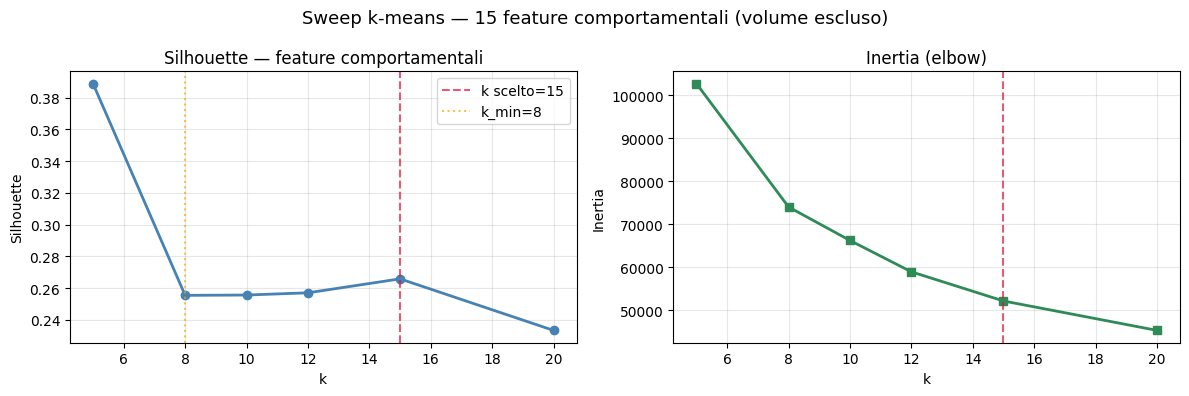

In [5]:
# Plot sweep
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(df_sweep["k"], df_sweep["silhouette"], marker="o", color="steelblue", linewidth=2)
axes[0].axvline(K_BEST, color="crimson", linestyle="--", alpha=0.7, label=f"k scelto={K_BEST}")
axes[0].axvline(8, color="orange", linestyle=":", alpha=0.7, label="k_min=8")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Silhouette")
axes[0].set_title("Silhouette — feature comportamentali")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(df_sweep["k"], df_sweep["inertia"], marker="s", color="seagreen", linewidth=2)
axes[1].axvline(K_BEST, color="crimson", linestyle="--", alpha=0.7)
axes[1].set_xlabel("k"); axes[1].set_ylabel("Inertia")
axes[1].set_title("Inertia (elbow)")
axes[1].grid(True, alpha=0.3)

plt.suptitle(f"Sweep k-means — 15 feature comportamentali (volume escluso)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/06_kmeans_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Clustering finale + sensitivity analysis (3 seed)

In [6]:
SEEDS = [42, 123, 999]
all_labels, all_sil = [], []

for seed in SEEDS:
    km  = KMeans(n_clusters=K_BEST, random_state=seed, n_init=10)
    lbl = km.fit_predict(X)
    sil = silhouette_score(X[sil_idx], lbl[sil_idx])
    all_labels.append(lbl)
    all_sil.append(sil)
    print(f"Seed {seed:>3}: silhouette={sil:.4f}")

ari_01 = adjusted_rand_score(all_labels[0], all_labels[1])
ari_02 = adjusted_rand_score(all_labels[0], all_labels[2])
ari_12 = adjusted_rand_score(all_labels[1], all_labels[2])
mean_ari = np.mean([ari_01, ari_02, ari_12])

print(f"\nARI inter-seed: {ari_01:.4f} / {ari_02:.4f} / {ari_12:.4f}")
print(f"ARI medio: {mean_ari:.4f} → {'STABILE' if mean_ari > 0.7 else 'INSTABILE'}")

best_seed_idx = int(np.argmax(all_sil))
LABELS_FINAL  = all_labels[best_seed_idx]
SIL_FINAL     = all_sil[best_seed_idx]
SEED_FINAL    = SEEDS[best_seed_idx]
print(f"\nPartizione definitiva: seed={SEED_FINAL}, silhouette={SIL_FINAL:.4f}")

Seed  42: silhouette=0.2658


Seed 123: silhouette=0.2644


Seed 999: silhouette=0.2659

ARI inter-seed: 0.9439 / 0.9890 / 0.9471
ARI medio: 0.9600 → STABILE

Partizione definitiva: seed=999, silhouette=0.2659


## 4. Validazione alternativa — Louvain su union k-NN

In [7]:
def build_union_knn_graph(X, k, agent_ids):
    nbrs = NearestNeighbors(n_neighbors=k + 1, metric="cosine").fit(X)
    distances, indices = nbrs.kneighbors(X)
    N = len(X)
    G = nx.Graph()
    G.add_nodes_from(range(N))
    for i in range(N):
        for j, dist in zip(indices[i, 1:], distances[i, 1:]):
            sim = max(0.0, 1.0 - float(dist))
            if G.has_edge(i, j):
                if sim > G[i][j]["weight"]:
                    G[i][j]["weight"] = sim
            else:
                G.add_edge(i, j, weight=sim)
    nx.set_node_attributes(G, dict(enumerate(agent_ids)), "agent_id")
    return G

print("Costruzione union k-NN (k=10) su feature comportamentali...")
G_sim = build_union_knn_graph(X, 10, agent_ids)
partition_louvain = community_louvain.best_partition(G_sim, weight="weight", random_state=42)
Q_louvain   = community_louvain.modularity(partition_louvain, G_sim, weight="weight")
n_louvain   = len(set(partition_louvain.values()))
lbl_louvain = [partition_louvain[i] for i in range(len(agent_ids))]

ari_km_lv = adjusted_rand_score(LABELS_FINAL, lbl_louvain)
print(f"Louvain: Q={Q_louvain:.4f}, n_community={n_louvain}")
print(f"ARI k-means vs Louvain: {ari_km_lv:.4f}")
print(f"Archi grafo similarita': {G_sim.number_of_edges():,}")

Costruzione union k-NN (k=10) su feature comportamentali...


Louvain: Q=0.8869, n_community=26
ARI k-means vs Louvain: 0.2369
Archi grafo similarita': 63,088


## 5. Salvataggio artefatti

In [8]:
cluster_df = pd.DataFrame({"agent_id": agent_ids, "cluster_id": LABELS_FINAL})
cluster_df.to_parquet("../data/cluster_assignments_v1.parquet", index=False)

df_check = pd.read_parquet("../data/cluster_assignments_v1.parquet")
assert df_check.shape == (N, 2) and df_check.isna().sum().sum() == 0
print(f"cluster_assignments_v1.parquet: {df_check.shape} — OK")

with open("../data/similarity_network_v1.pkl", "wb") as f:
    pickle.dump(G_sim, f)
print(f"similarity_network_v1.pkl: {G_sim.number_of_nodes()} nodi, {G_sim.number_of_edges()} archi")

cluster_assignments_v1.parquet: (9096, 2) — OK


similarity_network_v1.pkl: 9096 nodi, 63088 archi


## 6. Caratterizzazione cluster — heatmap profili medi

In [9]:
df_raw_merged = df_raw.merge(cluster_df, on="agent_id")
assert len(df_raw_merged) == N

# Usa TUTTE le 19 feature per il profilo (anche volume, per interpretazione)
cluster_profiles = df_raw_merged.groupby("cluster_id")[all_features].mean()
cluster_sizes    = cluster_df["cluster_id"].value_counts().rename("size")
n_clusters       = len(cluster_profiles)

print(f"k={K_BEST} cluster")
print(f"Dimensioni — min={cluster_sizes.min()}, max={cluster_sizes.max()}, "
      f"mediana={cluster_sizes.median():.0f}, media={cluster_sizes.mean():.0f}")
print(f"\nDimensioni per cluster:")
for cid, sz in cluster_sizes.sort_values(ascending=False).items():
    print(f"  C{cid}: {sz} ({sz/N*100:.1f}%)")

k=15 cluster
Dimensioni — min=172, max=2346, mediana=421, media=606

Dimensioni per cluster:
  C4: 2346 (25.8%)
  C13: 1499 (16.5%)
  C11: 725 (8.0%)
  C6: 659 (7.2%)
  C14: 533 (5.9%)
  C12: 518 (5.7%)
  C9: 432 (4.7%)
  C5: 421 (4.6%)
  C3: 392 (4.3%)
  C2: 386 (4.2%)
  C1: 372 (4.1%)
  C10: 253 (2.8%)
  C0: 213 (2.3%)
  C7: 175 (1.9%)
  C8: 172 (1.9%)


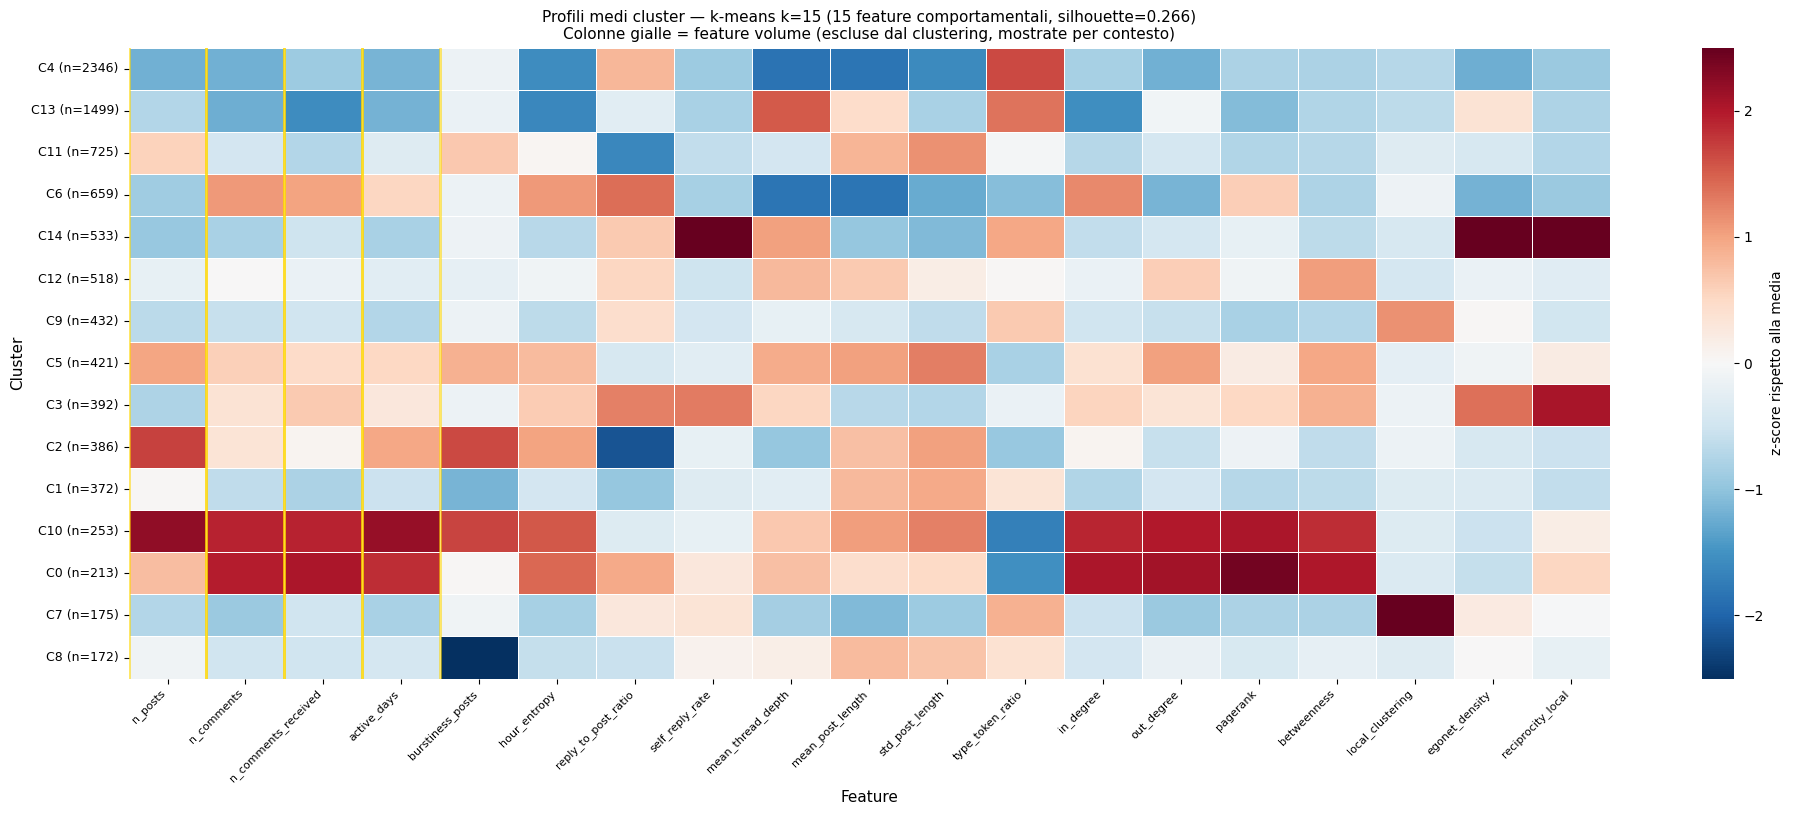

Figura salvata: 06_cluster_heatmap.png


In [10]:
ordered_idx = cluster_sizes.sort_values(ascending=False).index.tolist()
profiles_z  = cluster_profiles.loc[ordered_idx].apply(zscore, axis=0)

fig, ax = plt.subplots(figsize=(20, max(6, n_clusters * 0.55)))
sns.heatmap(
    profiles_z,
    cmap="RdBu_r", center=0, vmin=-2.5, vmax=2.5,
    linewidths=0.4, linecolor="white",
    xticklabels=all_features,
    yticklabels=[f"C{c} (n={cluster_sizes[c]})" for c in ordered_idx],
    cbar_kws={"label": "z-score rispetto alla media"},
    ax=ax
)
# Evidenzia le colonne volume (escluse dal clustering)
vol_positions = [all_features.index(f) for f in VOLUME_FEATURES]
for vp in vol_positions:
    ax.axvline(x=vp, color="gold", linewidth=2, alpha=0.6)
    ax.axvline(x=vp+1, color="gold", linewidth=2, alpha=0.6)

ax.set_title(
    f"Profili medi cluster — k-means k={K_BEST} (15 feature comportamentali, silhouette={SIL_FINAL:.3f})\n"
    f"Colonne gialle = feature volume (escluse dal clustering, mostrate per contesto)",
    fontsize=11
)
ax.set_xlabel("Feature", fontsize=11)
ax.set_ylabel("Cluster", fontsize=11)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/06_cluster_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salvata: 06_cluster_heatmap.png")

## 7. Distribuzione dimensioni cluster

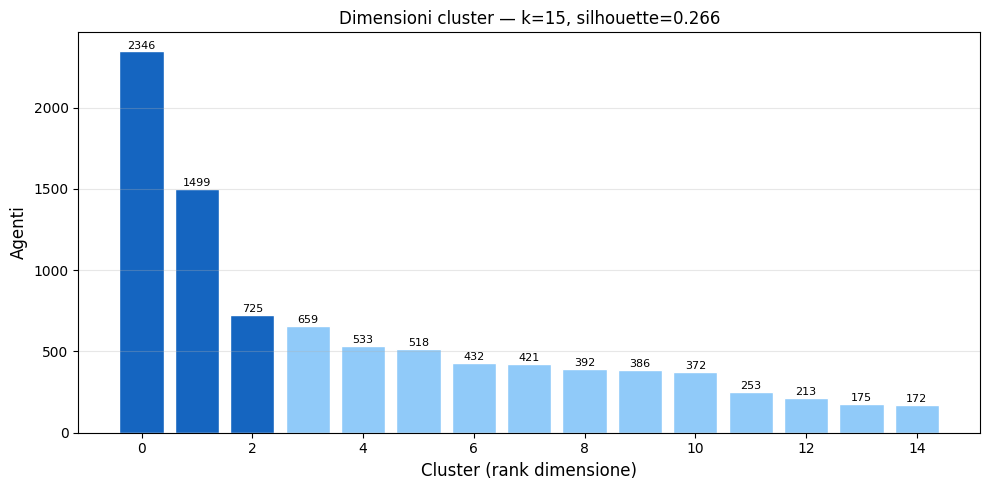

In [11]:
sizes_sorted = cluster_sizes.sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(max(10, n_clusters * 0.6), 5))
colors = ["#1565C0" if i < 3 else "#90CAF9" for i in range(len(sizes_sorted))]
bars = ax.bar(range(len(sizes_sorted)), sizes_sorted.values, color=colors, edgecolor="white")
ax.set_xlabel("Cluster (rank dimensione)", fontsize=12)
ax.set_ylabel("Agenti", fontsize=12)
ax.set_title(f"Dimensioni cluster — k={K_BEST}, silhouette={SIL_FINAL:.3f}", fontsize=12)
ax.grid(axis="y", alpha=0.3)
for i, bar in enumerate(bars):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{sizes_sorted.iloc[i]}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/06_cluster_size_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Visualizzazione PCA 2D

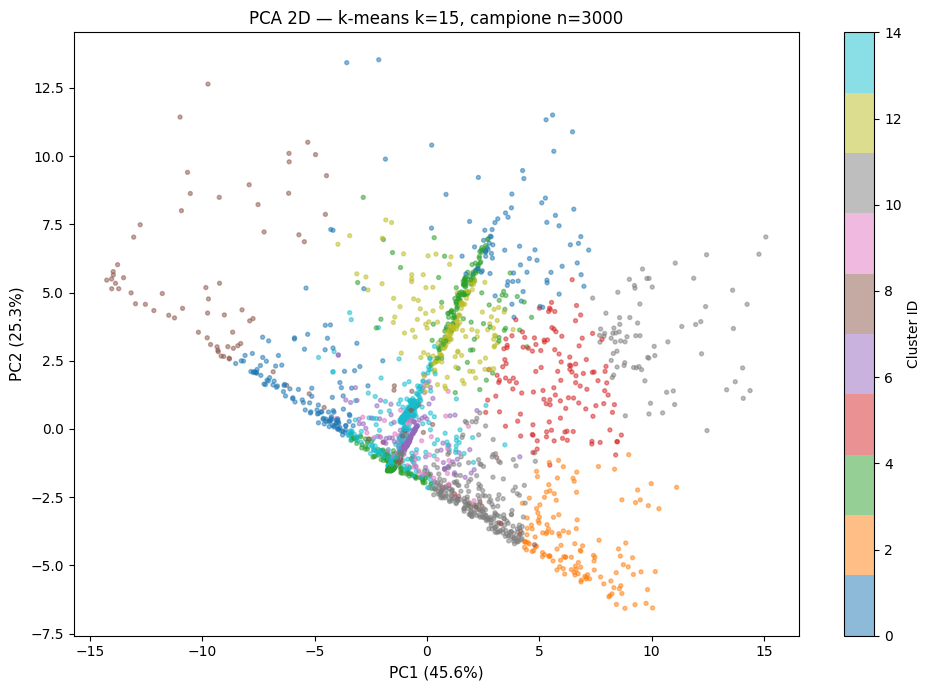

Varianza PC1+PC2: 70.9%


In [12]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
var_expl = pca.explained_variance_ratio_

np.random.seed(42)
plot_idx = np.random.choice(N, min(3000, N), replace=False)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    X_pca[plot_idx, 0], X_pca[plot_idx, 1],
    c=LABELS_FINAL[plot_idx], cmap="tab10", s=8, alpha=0.5
)
ax.set_xlabel(f"PC1 ({var_expl[0]*100:.1f}%)", fontsize=11)
ax.set_ylabel(f"PC2 ({var_expl[1]*100:.1f}%)", fontsize=11)
ax.set_title(f"PCA 2D — k-means k={K_BEST}, campione n=3000", fontsize=12)
plt.colorbar(scatter, ax=ax, label="Cluster ID")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/06_cluster_pca.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Varianza PC1+PC2: {sum(var_expl)*100:.1f}%")

## 9. Tabella di sintesi

In [13]:
os.makedirs("../docs", exist_ok=True)

md = [
    "# Risultati RQ2 — Similarity Network e Clustering v2 (giu 2026)\n\n",
    "## Scelte metodologiche\n\n",
    "| Parametro | Valore |\n",
    "|---|---|\n",
    f"| Feature usate | 15/19 (volume escluso) |\n",
    f"| Feature escluse | {', '.join(VOLUME_FEATURES)} |\n",
    f"| Metodo clustering | k-means |\n",
    f"| k ottimale | {K_BEST} |\n",
    f"| Criterio selezione | Silhouette max con k>=8 |\n",
    f"| Seed definitivo | {SEED_FINAL} |\n",
    "\n## Risultati\n\n",
    "| Metrica | Valore |\n",
    "|---|---|\n",
    f"| Silhouette | {SIL_FINAL:.4f} |\n",
    f"| ARI inter-seed medio | {mean_ari:.4f} |\n",
    f"| Numero cluster | {K_BEST} |\n",
    f"| Q Louvain (union k-NN k=10) | {Q_louvain:.4f} |\n",
    f"| ARI k-means vs Louvain | {ari_km_lv:.4f} |\n",
    "\n## Sweep k-means\n\n",
    df_sweep.to_markdown(index=False),
    "\n\n## Dimensioni cluster\n\n",
    "| Cluster | Agenti | % totale |\n",
    "|---|---|---|\n",
]
for cid, sz in sizes_sorted.items():
    md.append(f"| C{cid} | {sz} | {sz/N*100:.1f}% |\n")

with open("../docs/results_rq2.md", "w", encoding="utf-8") as f:
    f.writelines(md)

print("docs/results_rq2.md salvato.")
print(f"\nRiassunto: k={K_BEST}, silhouette={SIL_FINAL:.4f}, ARI={mean_ari:.4f}")

docs/results_rq2.md salvato.

Riassunto: k=15, silhouette=0.2659, ARI=0.9600
